Predicting Walmart Revenue Using Retail Sales Data

Objective

This analysis evaluates whether monthly U.S. retail sales data from FRED
can serve as a leading indicator for Walmart's quarterly revenue.

The key question is:

> Does retail sales data predict Walmart revenue better than a naive baseline?

To answer this, we:

- Compare a naive seasonal baseline against a retail-sales-based model
- Evaluate performance using out-of-sample testing
- Avoid look-ahead bias in feature construction
- Discuss limitations and business interpretation

In [34]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, \
    mean_absolute_error

import statsmodels.api as sm

Load Data
1. Monthly retail sales data from FRED
2. Quarterly Walmart revenue data

In [35]:
retail = pd.read_csv('data/retail_sales_fred.csv')
revenue = pd.read_csv('data/walmart_revenue.csv')

display(retail.head())
display(revenue.head())

,date,value
0,2010-01-01,302325.0
1,2010-02-01,302310.0
2,2010-03-01,309525.0
3,2010-04-01,312143.0
4,2010-05-01,309158.0


,date,value
0,2010-01-31,1.135940e+11
1,2010-04-30,9.981100e+10
2,2010-07-31,1.037260e+11
3,2010-10-31,1.019520e+11
4,2011-01-31,1.163600e+11


Data Preparation

1. The date columns are converted into datetime format to enable
2.  time-series operations and resampling.

In [36]:
retail['date'] = pd.to_datetime(retail['date'])
revenue['date'] = pd.to_datetime(revenue['date'])

retail["value"] = pd.to_numeric(retail["value"], errors="coerce")
revenue["value"] = pd.to_numeric(revenue["value"], errors="coerce")

print(retail.info())
print(revenue.info())

# Missing Values Check
print(retail.isnull().sum())
print(revenue.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    195 non-null    datetime64[us]
 1   value   195 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 3.2 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    65 non-null     datetime64[us]
 1   value   65 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.1 KB
None
date     0
value    0
dtype: int64
date     0
value    0
dtype: int64


Initial Visualization

We visualize both datasets to understand long-term trends, seasonality, and structural changes over time.

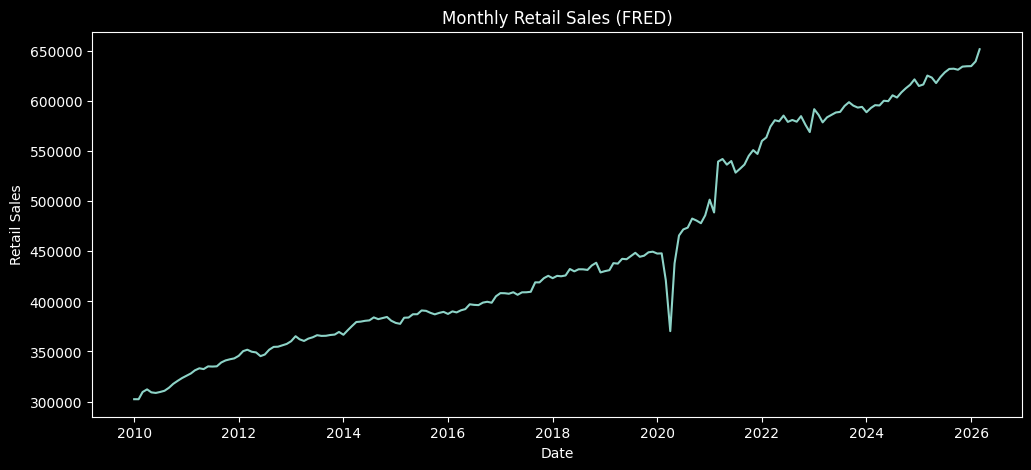

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(retail["date"], retail["value"])

plt.title("Monthly Retail Sales (FRED)")
plt.xlabel("Date")
plt.ylabel("Retail Sales")

plt.show()

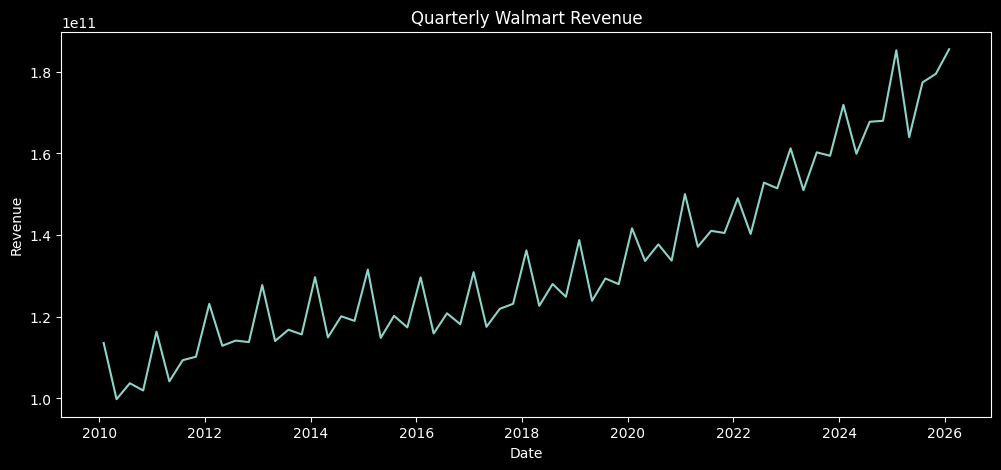

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(revenue["date"], revenue["value"])

plt.title("Quarterly Walmart Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

Quarterly Aggregation

Retail sales data is reported monthly, while Walmart revenue is quarterly.

1. To align both datasets for modeling, the monthly retail sales series
2. is aggregated into quarterly frequency.

In [39]:
# Set date as index
retail_q = retail.set_index("date").copy()

# Convert monthly retail sales into quarterly totals
retail_q = (
    retail_q["value"]
    .resample("QE")
    .sum()
    .reset_index()
)

retail_q.columns = ["date", "retail_sales"]

In [40]:
display(retail_q.head())
display(revenue.head())

,date,retail_sales
0,2010-03-31,914160.0
1,2010-06-30,929889.0
2,2010-09-30,934089.0
3,2010-12-31,961815.0
4,2011-03-31,984884.0


,date,value
0,2010-01-31,1.135940e+11
1,2010-04-30,9.981100e+10
2,2010-07-31,1.037260e+11
3,2010-10-31,1.019520e+11
4,2011-01-31,1.163600e+11


Quarter Alignment

Retail sales and Walmart revenue use different date conventions.

To align both datasets consistently, dates are converted into quarterly periods.
This avoids mismatches caused by fiscal quarter-end reporting dates.

In [41]:
retail_q["quarter"] = retail_q["date"].dt.to_period("Q")
revenue["quarter"] = revenue["date"].dt.to_period("Q")

display(retail_q.head())
display(revenue.head())

,date,retail_sales,quarter
0,2010-03-31,914160.0,2010Q1
1,2010-06-30,929889.0,2010Q2
2,2010-09-30,934089.0,2010Q3
3,2010-12-31,961815.0,2010Q4
4,2011-03-31,984884.0,2011Q1


,date,value,quarter
0,2010-01-31,1.135940e+11,2010Q1
1,2010-04-30,9.981100e+10,2010Q2
2,2010-07-31,1.037260e+11,2010Q3
3,2010-10-31,1.019520e+11,2010Q4
4,2011-01-31,1.163600e+11,2011Q1


Merge Quarterly Datasets

After aligning both datasets to quarterly periods,
the retail sales and Walmart revenue series are merged
into a single modeling dataset.

In [42]:
merged = pd.merge(
    retail_q,
    revenue,
    on="quarter",
    how="inner"
)

In [43]:
merged = merged[[
    "quarter",
    "retail_sales",
    "value"
]]

# Rename revenue column
merged = merged.rename(columns={
    "value": "walmart_revenue"
})

In [44]:
display(merged.head())

,quarter,retail_sales,walmart_revenue
0,2010Q1,914160.0,1.135940e+11
1,2010Q2,929889.0,9.981100e+10
2,2010Q3,934089.0,1.037260e+11
3,2010Q4,961815.0,1.019520e+11
4,2011Q1,984884.0,1.163600e+11


Year-over-Year Growth Rates

Instead of modeling raw values directly, year-over-year (YoY) growth
rates are calculated for both retail sales and Walmart revenue.

YoY growth helps reduce the impact of long-term trends and seasonality,
making the relationship between the two series easier to interpret.

In [45]:
merged["retail_yoy"] = merged["retail_sales"].pct_change(4)

merged["revenue_yoy"] = merged["walmart_revenue"].pct_change(4)

In [46]:
display(merged.head(10))

,quarter,retail_sales,walmart_revenue,retail_yoy,revenue_yoy
0,2010Q1,914160.0,1.135940e+11,NaN,NaN
1,2010Q2,929889.0,9.981100e+10,NaN,NaN
2,2010Q3,934089.0,1.037260e+11,NaN,NaN
3,2010Q4,961815.0,1.019520e+11,NaN,NaN
4,2011Q1,984884.0,1.163600e+11,0.077365,0.024350
5,2011Q2,1000706.0,1.041890e+11,0.076156,0.043863
6,2011Q3,1009096.0,1.093660e+11,0.080300,0.054374
7,2011Q4,1026365.0,1.102260e+11,0.067113,0.081156
8,2012Q1,1047749.0,1.231690e+11,0.063830,0.058517
9,2012Q2,1044125.0,1.129010e+11,0.043388,0.083617


Remove Missing Values

The first four rows contain missing YoY growth values because
a full prior year is required for year-over-year calculations.

These rows are removed before modeling.

In [47]:
model_data = merged.dropna().copy()

# Reset index
model_data = model_data.reset_index(drop=True)

In [48]:
display(model_data.head())

,quarter,retail_sales,walmart_revenue,retail_yoy,revenue_yoy
0,2011Q1,984884.0,1.163600e+11,0.077365,0.024350
1,2011Q2,1000706.0,1.041890e+11,0.076156,0.043863
2,2011Q3,1009096.0,1.093660e+11,0.080300,0.054374
3,2011Q4,1026365.0,1.102260e+11,0.067113,0.081156
4,2012Q1,1047749.0,1.231690e+11,0.063830,0.058517


Relationship Between Retail Sales Growth and Revenue Growth

The following visualization compares retail sales YoY growth
against Walmart revenue YoY growth to inspect whether a
relationship may exist between the two series.

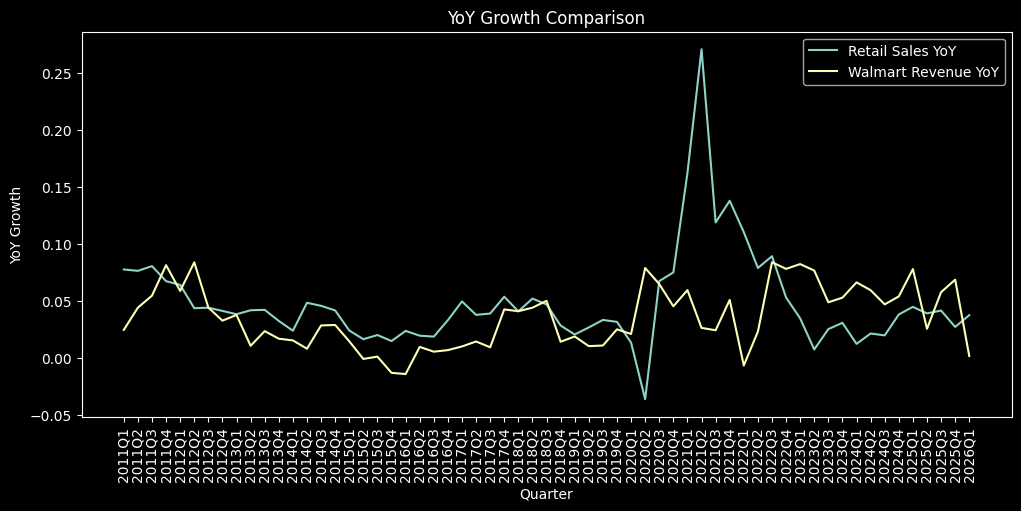

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    model_data["quarter"].astype(str),
    model_data["retail_yoy"],
    label="Retail Sales YoY"
)

plt.plot(
    model_data["quarter"].astype(str),
    model_data["revenue_yoy"],
    label="Walmart Revenue YoY"
)

plt.xticks(rotation=90)

plt.title("YoY Growth Comparison")
plt.xlabel("Quarter")
plt.ylabel("YoY Growth")

plt.legend()

plt.show()

Naive Baseline Model

A simple baseline is created using persistence forecasting.

The baseline predicts that the next quarter's Walmart revenue growth
will be equal to the previous observed quarter's growth.

This provides a benchmark against which the retail-sales-based model
can be evaluated.

In [50]:
model_data["baseline_pred"] = model_data["revenue_yoy"].shift(1)

In [51]:
# Remove missing baseline row
model_data = model_data.dropna().reset_index(drop=True)

In [52]:
display(model_data.head())

,quarter,retail_sales,walmart_revenue,retail_yoy,revenue_yoy,baseline_pred
0,2011Q2,1000706.0,1.041890e+11,0.076156,0.043863,0.024350
1,2011Q3,1009096.0,1.093660e+11,0.080300,0.054374,0.043863
2,2011Q4,1026365.0,1.102260e+11,0.067113,0.081156,0.054374
3,2012Q1,1047749.0,1.231690e+11,0.063830,0.058517,0.081156
4,2012Q2,1044125.0,1.129010e+11,0.043388,0.083617,0.058517


Baseline Evaluation

The persistence baseline is evaluated using Mean Absolute Percentage Error (MAPE)
and Root Mean Squared Error (RMSE).

These metrics establish the benchmark performance that the predictive model
must outperform.

In [53]:
# Actual values
y_true = model_data["revenue_yoy"]

# Baseline predictions
y_baseline = model_data["baseline_pred"]

# MAE
baseline_mae = mean_absolute_error(
    y_true,
    y_baseline
)

# RMSE
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_baseline
    )
)

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MAE: 0.0171
Baseline RMSE: 0.0237


Retail-Sales-Based Prediction Model

A linear regression model is used to test whether retail sales growth
contains predictive information about Walmart revenue growth.

Retail sales YoY growth is used as the explanatory variable,
while Walmart revenue YoY growth is the target variable.

Train-Test Split

To avoid look-ahead bias, the dataset is split chronologically.

Earlier quarters are used for training,
while later quarters are reserved for out-of-sample evaluation.

In [54]:
# Features and target

X = model_data[["retail_yoy"]]

y = model_data["revenue_yoy"]

In [55]:
# Split index

split_index = int(len(model_data) * 0.8)

# Train data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Test data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

In [56]:
# Initialize model

model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
# Predict on test set

y_pred = model.predict(X_test)

In [58]:
# MAE
model_mae = mean_absolute_error(
    y_test,
    y_pred
)

# RMSE
model_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print(f"Model MAE: {model_mae:.4f}")
print(f"Model RMSE: {model_rmse:.4f}")

Model MAE: 0.0298
Model RMSE: 0.0323


Prediction Comparison

The following visualization compares actual Walmart revenue growth
against predictions generated by the retail-sales regression model.

In [59]:
comparison = pd.DataFrame(dict(
    quarter=model_data["quarter"].iloc[split_index:].astype(str),
    actual=y_test.values,
    predicted=y_pred
))

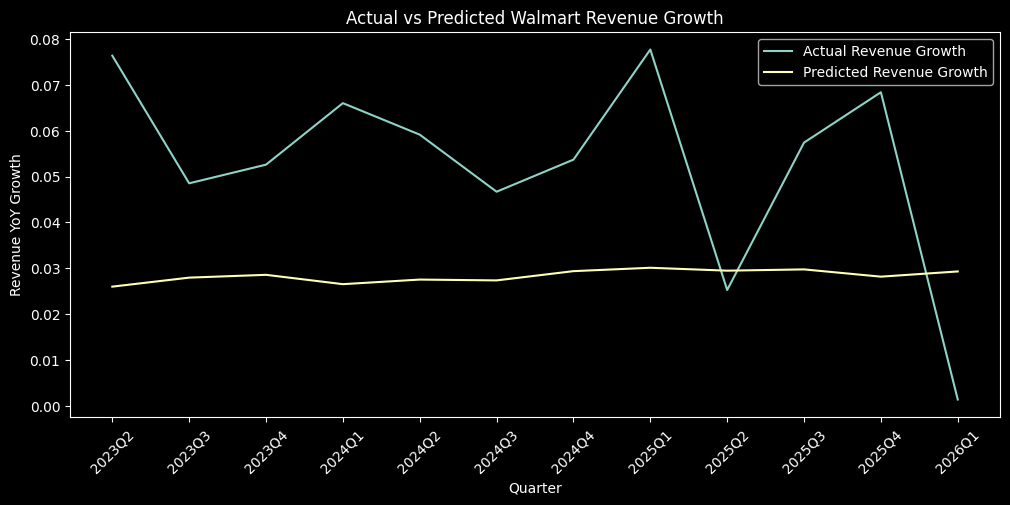

In [60]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparison["quarter"],
    comparison["actual"],
    label="Actual Revenue Growth"
)

plt.plot(
    comparison["quarter"],
    comparison["predicted"],
    label="Predicted Revenue Growth"
)

plt.xticks(rotation=45)

plt.title("Actual vs Predicted Walmart Revenue Growth")
plt.xlabel("Quarter")
plt.ylabel("Revenue YoY Growth")

plt.legend()

plt.show()

Lagged Retail Sales Feature

Retail sales may influence Walmart revenue with a delay rather than immediately.

To test this possibility, a lagged retail sales growth feature is added
using the previous quarter's retail sales growth.

In [61]:
# Previous quarter retail growth

model_data["retail_yoy_lag1"] = model_data["retail_yoy"].shift(1)
model_data_lag = model_data.dropna().reset_index(drop=True)

In [62]:
X_lag = model_data_lag[[
    "retail_yoy",
    "retail_yoy_lag1"
]]

y_lag = model_data_lag["revenue_yoy"]

In [63]:
split_index_lag = int(len(model_data_lag) * 0.8)

X_train_lag = X_lag.iloc[:split_index_lag]
X_test_lag = X_lag.iloc[split_index_lag:]

y_train_lag = y_lag.iloc[:split_index_lag]
y_test_lag = y_lag.iloc[split_index_lag:]

In [64]:
lag_model = LinearRegression()

lag_model.fit(X_train_lag, y_train_lag)

y_pred_lag = lag_model.predict(X_test_lag)

In [65]:
lag_mae = mean_absolute_error(
    y_test_lag,
    y_pred_lag
)

lag_rmse = np.sqrt(
    mean_squared_error(
        y_test_lag,
        y_pred_lag
    )
)

print(f"Lag Model MAE: {lag_mae:.4f}")
print(f"Lag Model RMSE: {lag_rmse:.4f}")

Lag Model MAE: 0.0300
Lag Model RMSE: 0.0325


Model Comparison Summary

The table below compares forecasting performance across the naive baseline,
the retail-sales regression model, and the lagged retail-sales model.

In [66]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Retail Regression",
        "Lagged Retail Regression"
    ],
    "MAE": [
        baseline_mae,
        model_mae,
        lag_mae
    ],
    "RMSE": [
        baseline_rmse,
        model_rmse,
        lag_rmse
    ]
})

results

,Model,MAE,RMSE
0,Naive Baseline,0.017131,0.023695
1,Retail Regression,0.029782,0.032288
2,Lagged Retail Regression,0.030041,0.032504


# Final Conclusion

* This analysis evaluated whether U.S. retail sales data from FRED
could improve prediction of Walmart quarterly revenue relative
to a naive persistence baseline.

* Although retail sales growth showed some directional relationship
with Walmart revenue growth, both the direct regression model
and lagged retail-sales model underperformed the naive baseline
during out-of-sample evaluation.

* The results suggest that Walmart’s own historical revenue behavior
contains stronger predictive information than broader retail sales
data in this setup.

* Additionally, the COVID period introduced structural changes
in consumer spending patterns that may have weakened the stability
of the relationship between retail sales and Walmart revenue.

* Overall, retail sales data alone did not provide incremental
forecasting improvement over a simple persistence-based approach.